# 🧠 Step 2 — Feature Extraction (ESM-2 Embeddings)

**Protein Function Prediction Using Genomic Language Model (ESM-2)**

Generates **protein embeddings** using Meta's **ESM-2** language model.
Each protein sequence → fixed-size vector encoding structural, evolutionary & functional info.

In [1]:
import os
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# ─── Configuration ───
PROJECT_ROOT = os.path.dirname(os.path.abspath('__file__'))
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
PLOTS_DIR = os.path.join(PROJECT_ROOT, 'results', 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

ESM_MODEL_NAME = 'facebook/esm2_t6_8M_UR50D'   # 8M params; fast on CPU
EMBEDDING_DIM = 320
BATCH_SIZE = 8
MAX_LENGTH = 1022
SEED = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.style.use('dark_background')
COLORS = ['#00D4FF', '#FF6B6B', '#4ECDC4', '#FFE66D', '#A855F7', '#F97316']

print(f'🖥️  Device      : {DEVICE}')
print(f'🧠 ESM-2 model : {ESM_MODEL_NAME}')
print(f'📐 Embedding   : {EMBEDDING_DIM}d')

🖥️  Device      : cpu
🧠 ESM-2 model : facebook/esm2_t6_8M_UR50D
📐 Embedding   : 320d


## 2.1 — Load ESM-2 Model

In [2]:
print('📥 Loading ESM-2 model and tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(ESM_MODEL_NAME)
esm_model = AutoModel.from_pretrained(ESM_MODEL_NAME).to(DEVICE)
esm_model.eval()

total_params = sum(p.numel() for p in esm_model.parameters())
print(f'✅ Loaded: {total_params/1e6:.1f}M parameters, hidden={esm_model.config.hidden_size}')

📥 Loading ESM-2 model and tokenizer...


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

C:\Users\Abhishek\.gemini\antigravity\scratch\Work_PLM\Work_PLM\protein_function_prediction\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Abhishek\.cache\huggingface\hub\models--facebook--esm2_t6_8M_UR50D. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Loaded: 7.5M parameters, hidden=320


## 2.2 — Embedding Extraction

In [3]:
def extract_embeddings(sequences, batch_size=BATCH_SIZE):
    """Mean-pooled ESM-2 embeddings for a list of protein sequences."""
    all_embeddings = []
    for i in tqdm(range(0, len(sequences), batch_size), desc='Embedding'):
        batch = list(sequences[i:i + batch_size])
        encoded = tokenizer(batch, padding=True, truncation=True,
                            max_length=MAX_LENGTH, return_tensors='pt')
        encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
        with torch.no_grad():
            out = esm_model(**encoded)
        hidden = out.last_hidden_state
        mask = encoded['attention_mask'].unsqueeze(-1)
        pooled = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        all_embeddings.append(pooled.cpu().numpy())
        del encoded, out, hidden, mask
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return np.concatenate(all_embeddings, axis=0)

print('✅ Extract function ready')

✅ Extract function ready


## 2.3 — Process All Splits

In [4]:
embeddings = {}
for split in ['train', 'val', 'test']:
    seqs = np.load(os.path.join(PROCESSED_DIR, f'sequences_{split}.npy'), allow_pickle=True)
    print(f'\n🔄 {split.upper()}: {len(seqs)} sequences')
    emb = extract_embeddings(seqs)
    out_path = os.path.join(PROCESSED_DIR, f'embeddings_{split}.npy')
    np.save(out_path, emb)
    embeddings[split] = emb
    print(f'💾 {emb.shape} → {out_path}')

print('\n✅ All embeddings extracted!')


🔄 TRAIN: 1569 sequences


Embedding:   0%|          | 0/197 [00:00<?, ?it/s]

💾 (1569, 320) → C:\Users\Abhishek\.gemini\antigravity\scratch\Work_PLM\Work_PLM\protein_function_prediction\data\processed\embeddings_train.npy

🔄 VAL: 197 sequences


Embedding:   0%|          | 0/25 [00:00<?, ?it/s]

💾 (197, 320) → C:\Users\Abhishek\.gemini\antigravity\scratch\Work_PLM\Work_PLM\protein_function_prediction\data\processed\embeddings_val.npy

🔄 TEST: 197 sequences


Embedding:   0%|          | 0/25 [00:00<?, ?it/s]

💾 (197, 320) → C:\Users\Abhishek\.gemini\antigravity\scratch\Work_PLM\Work_PLM\protein_function_prediction\data\processed\embeddings_test.npy

✅ All embeddings extracted!


## 2.4 — Embedding Quality Check

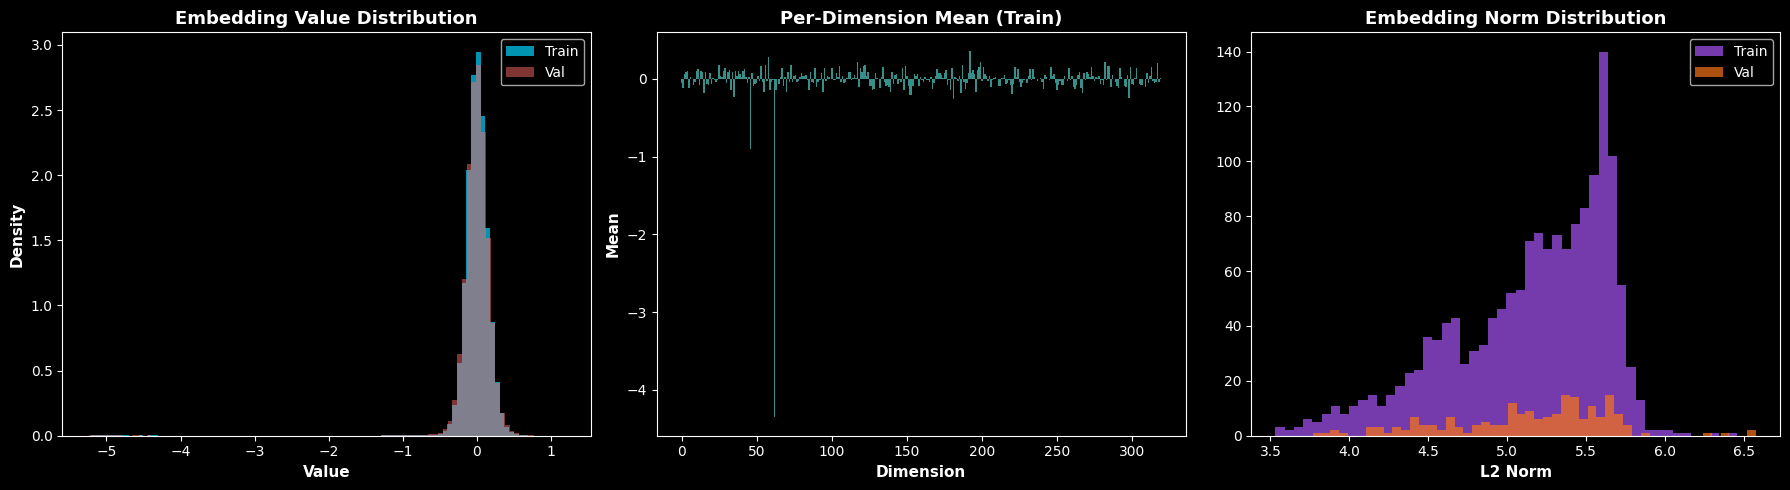

✅ Embedding quality plots saved!


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Value distribution
ax = axes[0]
ax.hist(embeddings['train'].flatten(), bins=100, color=COLORS[0], alpha=0.7, density=True, label='Train')
ax.hist(embeddings['val'].flatten(), bins=100, color=COLORS[1], alpha=0.5, density=True, label='Val')
ax.set_xlabel('Value', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('Embedding Value Distribution', fontsize=13, fontweight='bold')
ax.legend()

# 2. Per-dimension mean
ax = axes[1]
ax.bar(range(EMBEDDING_DIM), embeddings['train'].mean(axis=0), color=COLORS[2], alpha=0.7, width=1.0)
ax.set_xlabel('Dimension', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean', fontsize=11, fontweight='bold')
ax.set_title('Per-Dimension Mean (Train)', fontsize=13, fontweight='bold')

# 3. Norm distribution
ax = axes[2]
for split, color in [('train', COLORS[4]), ('val', COLORS[5])]:
    norms = np.linalg.norm(embeddings[split], axis=1)
    ax.hist(norms, bins=50, color=color, alpha=0.7, label=split.title())
ax.set_xlabel('L2 Norm', fontsize=11, fontweight='bold')
ax.set_title('Embedding Norm Distribution', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'embedding_quality.png'), dpi=300, bbox_inches='tight')
plt.show()
print('✅ Embedding quality plots saved!')

---
### ✅ Feature Extraction Complete!
**Next →** Open `03_train.ipynb`